# Importing Necessary Packages

In [ ]:
import os
import numpy as np
import zipfile
import tarfile
import gzip
import nibabel as nib
import matplotlib.pyplot as plt
from io import BytesIO
from google.colab import drive

# Unzipping the dataset

In [ ]:
# Unzipping Data from Google Drive
drive.mount('/content/drive')
zipped_data = "/content/drive/MyDrive/ColabData/GP-Datasets/brats-2021-task1.zip"
extract_path = "/content/brats-2021-task1"
with zipfile.ZipFile(zipped_data, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Mounted at /content/drive


In [ ]:
tar_training_data = extract_path + "/BraTS2021_Training_Data.tar"
training_data_path = extract_path + '/training_data'
with tarfile.open(tar_training_data, 'r') as tar_ref:
    tar_ref.extractall(training_data_path)
os.remove(tar_training_data)

In [ ]:
print(f"#Samples: {len(os.listdir(training_data_path))}")

#Samples: 1252


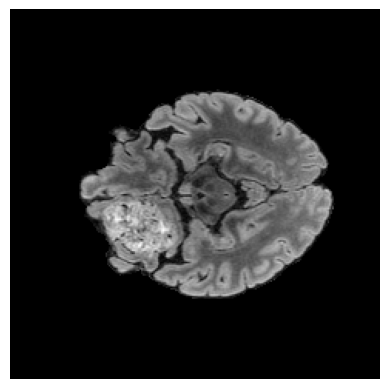

240 240 155


In [143]:
first_sample_path = training_data_path + "/BraTS2021_00000/BraTS2021_00000_flair.nii.gz"
image = nib.load(first_sample_path)
image_data = image.get_fdata()
plt.imshow(image_data[:, :, 60], cmap='gray')  # Display a slice of the image
plt.axis('off')  # Turn off the axes
plt.show()
print(image.shape[0], image.shape[1], image.shape[2])

# Measuring Contrast of each Voxel

In [85]:
def measure_contrast(nii_image):
  # Getting the Image as a 3D Array of values
  image_arr = nii_image.get_fdata()
  output_arr = np.zeros(nii_image.shape)
  # Defining a filter to measure the contrast
  contrast_filter = np.ones((3, 3, 3)) * -1
  contrast_filter[1, 1, 1] = 26
  # # Passing the Filter over the image
  for i in range(1, image_arr.shape[0] - 1):
    for j in range(1, image_arr.shape[1] - 1):
      for k in range(1, image_arr.shape[2] - 1):
        region = image_arr[i - 1 : i + 2, j - 1 : j + 2, k - 1 : k + 2]
        output_arr[i, j, k] = (region * contrast_filter).sum() / output_arr.size
  print(output_arr.sum())

# Measuring Histogram Flatness

In [136]:
def measure_histogram_flatness(nii_image):
  # Getting the Image as a 3D Array of values
  image_arr = nii_image.get_fdata()
  _, histo_values = np.unique(image_arr, return_counts=True)
  # Adding Zero Bins to Histogram
  zero_bins = np.zeros(2 ** 16 - histo_values.size)
  all_histo_values = np.concatenate((histo_values, zero_bins))
  # Calculating Average Value Stored in the Histogram
  mean_histo_value = np.sum(all_histo_values) / (2 ** 16)
  # Calculating SD and Variance of the Histogram
  sd = histo_values - mean_histo_value
  return np.sum(sd * sd) / (2 ** 16)

# Measuring the SD of local change in contrast.

In [170]:
def measure_sd_local_contrast_change(enhanced_nii_image, original_nii_image):
  # Getting the Image as a 3D Array of values
  enhanced_image_arr = enhanced_nii_image.get_fdata()
  original_image_arr = original_nii_image.get_fdata()
  # Setting zero voxels to -1 to do division
  original_image_arr[original_image_arr == 0] = -1
  # Measuring Change in Local Contrast
  contrast_change = enhanced_image_arr / original_image_arr
  contrast_change[contrast_change < 0] = enhanced_image_arr[contrast_change < 0]
  # Measuring Mean Change
  mean_contrast_change = np.mean(contrast_change)
  # Measuring SD of the Change
  sd_contrast_change = contrast_change - mean_contrast_change
  sd_contrast_change = np.sum(sd_contrast_change * sd_contrast_change)
  return sd_contrast_change / original_image_arr.size